# はじめてのAIリテラシー

## 14-6 データ活用実践2（教師あり学習 ― 回帰）

### データセットの読み込み

In [1]:
import pandas as pd
import numpy as np

# カリフォルニア州の各地域内の住宅価格のデータセット
# https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html

from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()    # housing : Bunch ≒ dict
# housing.data          = housing['data']           : ndarray   : 説明変数（独立変数）
# housing.feature_names = housing['feature_names']  : list      : 変数名のリスト
# housing.target        = housing['target']         : ndarray   : 目的変数（従属変数）
# housing.DESCR         = housing['DESCR']          : string    : データセットの概要

# print(housing.DESCR)

説明変数：

    -  (MedInc)     世帯所得の中央値
    -  (HouseAge)   築年数の中央値
    -  (AveRooms)   部屋数の平均値
    -  (AveBedrms)  寝室数の平均値
    -  (Population) ブロックの人口
    -  (AveOccup)   世帯人数の平均値
    -  (Latitude)   ブロックの緯度
    -  (Longitude)  ブロックの経度

目的変数は住宅価格の中央値 (MedHouseVal) である．
十万ドル（$100,000）単位で表示される．

In [2]:
#　説明変数をデータフレームに
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# 位置情報の変換データを追加
# df['lpl'] = df.Latitude + df.Longitude  # 南西 → 北東
# df['lml'] = df.Latitude - df.Longitude  # 南東 → 北西

# lml の2つのピークの近い方との差の絶対値 - たぶんロサンゼルスとサンフランシスコの
# 近い方との距離を使うと、もっと精密になるかも
# df['ur'] = np.where(abs(df['lml']-152) < abs(df['lml']-160), abs(df['lml']-152), abs(df['lml']-160))

#　目的変数をデータフレームに追加
df['MedHouseVal'] = housing.target

# 外れ値の除去
# q = df.quantile(0.99)
# df = df[df.HouseAge < q.HouseAge]
# df = df[df.AveRooms < q.AveRooms]
# df = df[df.AveBedrms < q.AveBedrms]
# df = df[df.Population < q.Population]
# df = df[df.AveOccup < q.AveOccup]
# df = df[df.lpl < q.lpl]
# df = df[df.ur < q.ur]
# df = df[df.MedHouseVal < q.MedHouseVal]

df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [3]:
# 欠損値の確認（各列の Non-Null を数える）
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# 基本統計量の確認
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


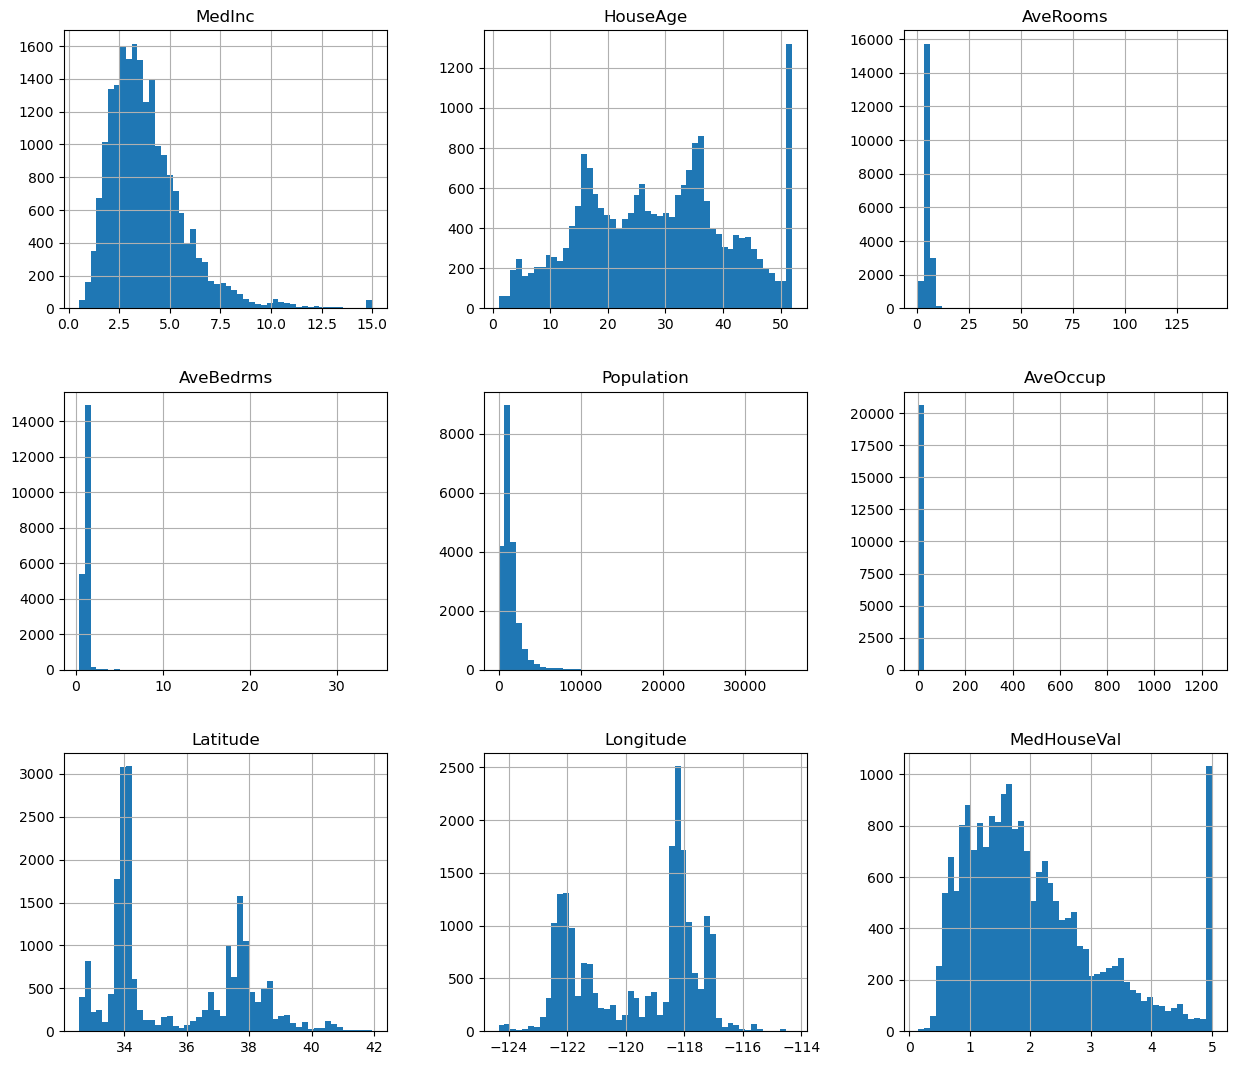

In [5]:
# ... の図示
import matplotlib.pyplot as plt
df.hist(bins=50, figsize=(15, 13))
# plt.savefig('housing_hist.png')
plt.show()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


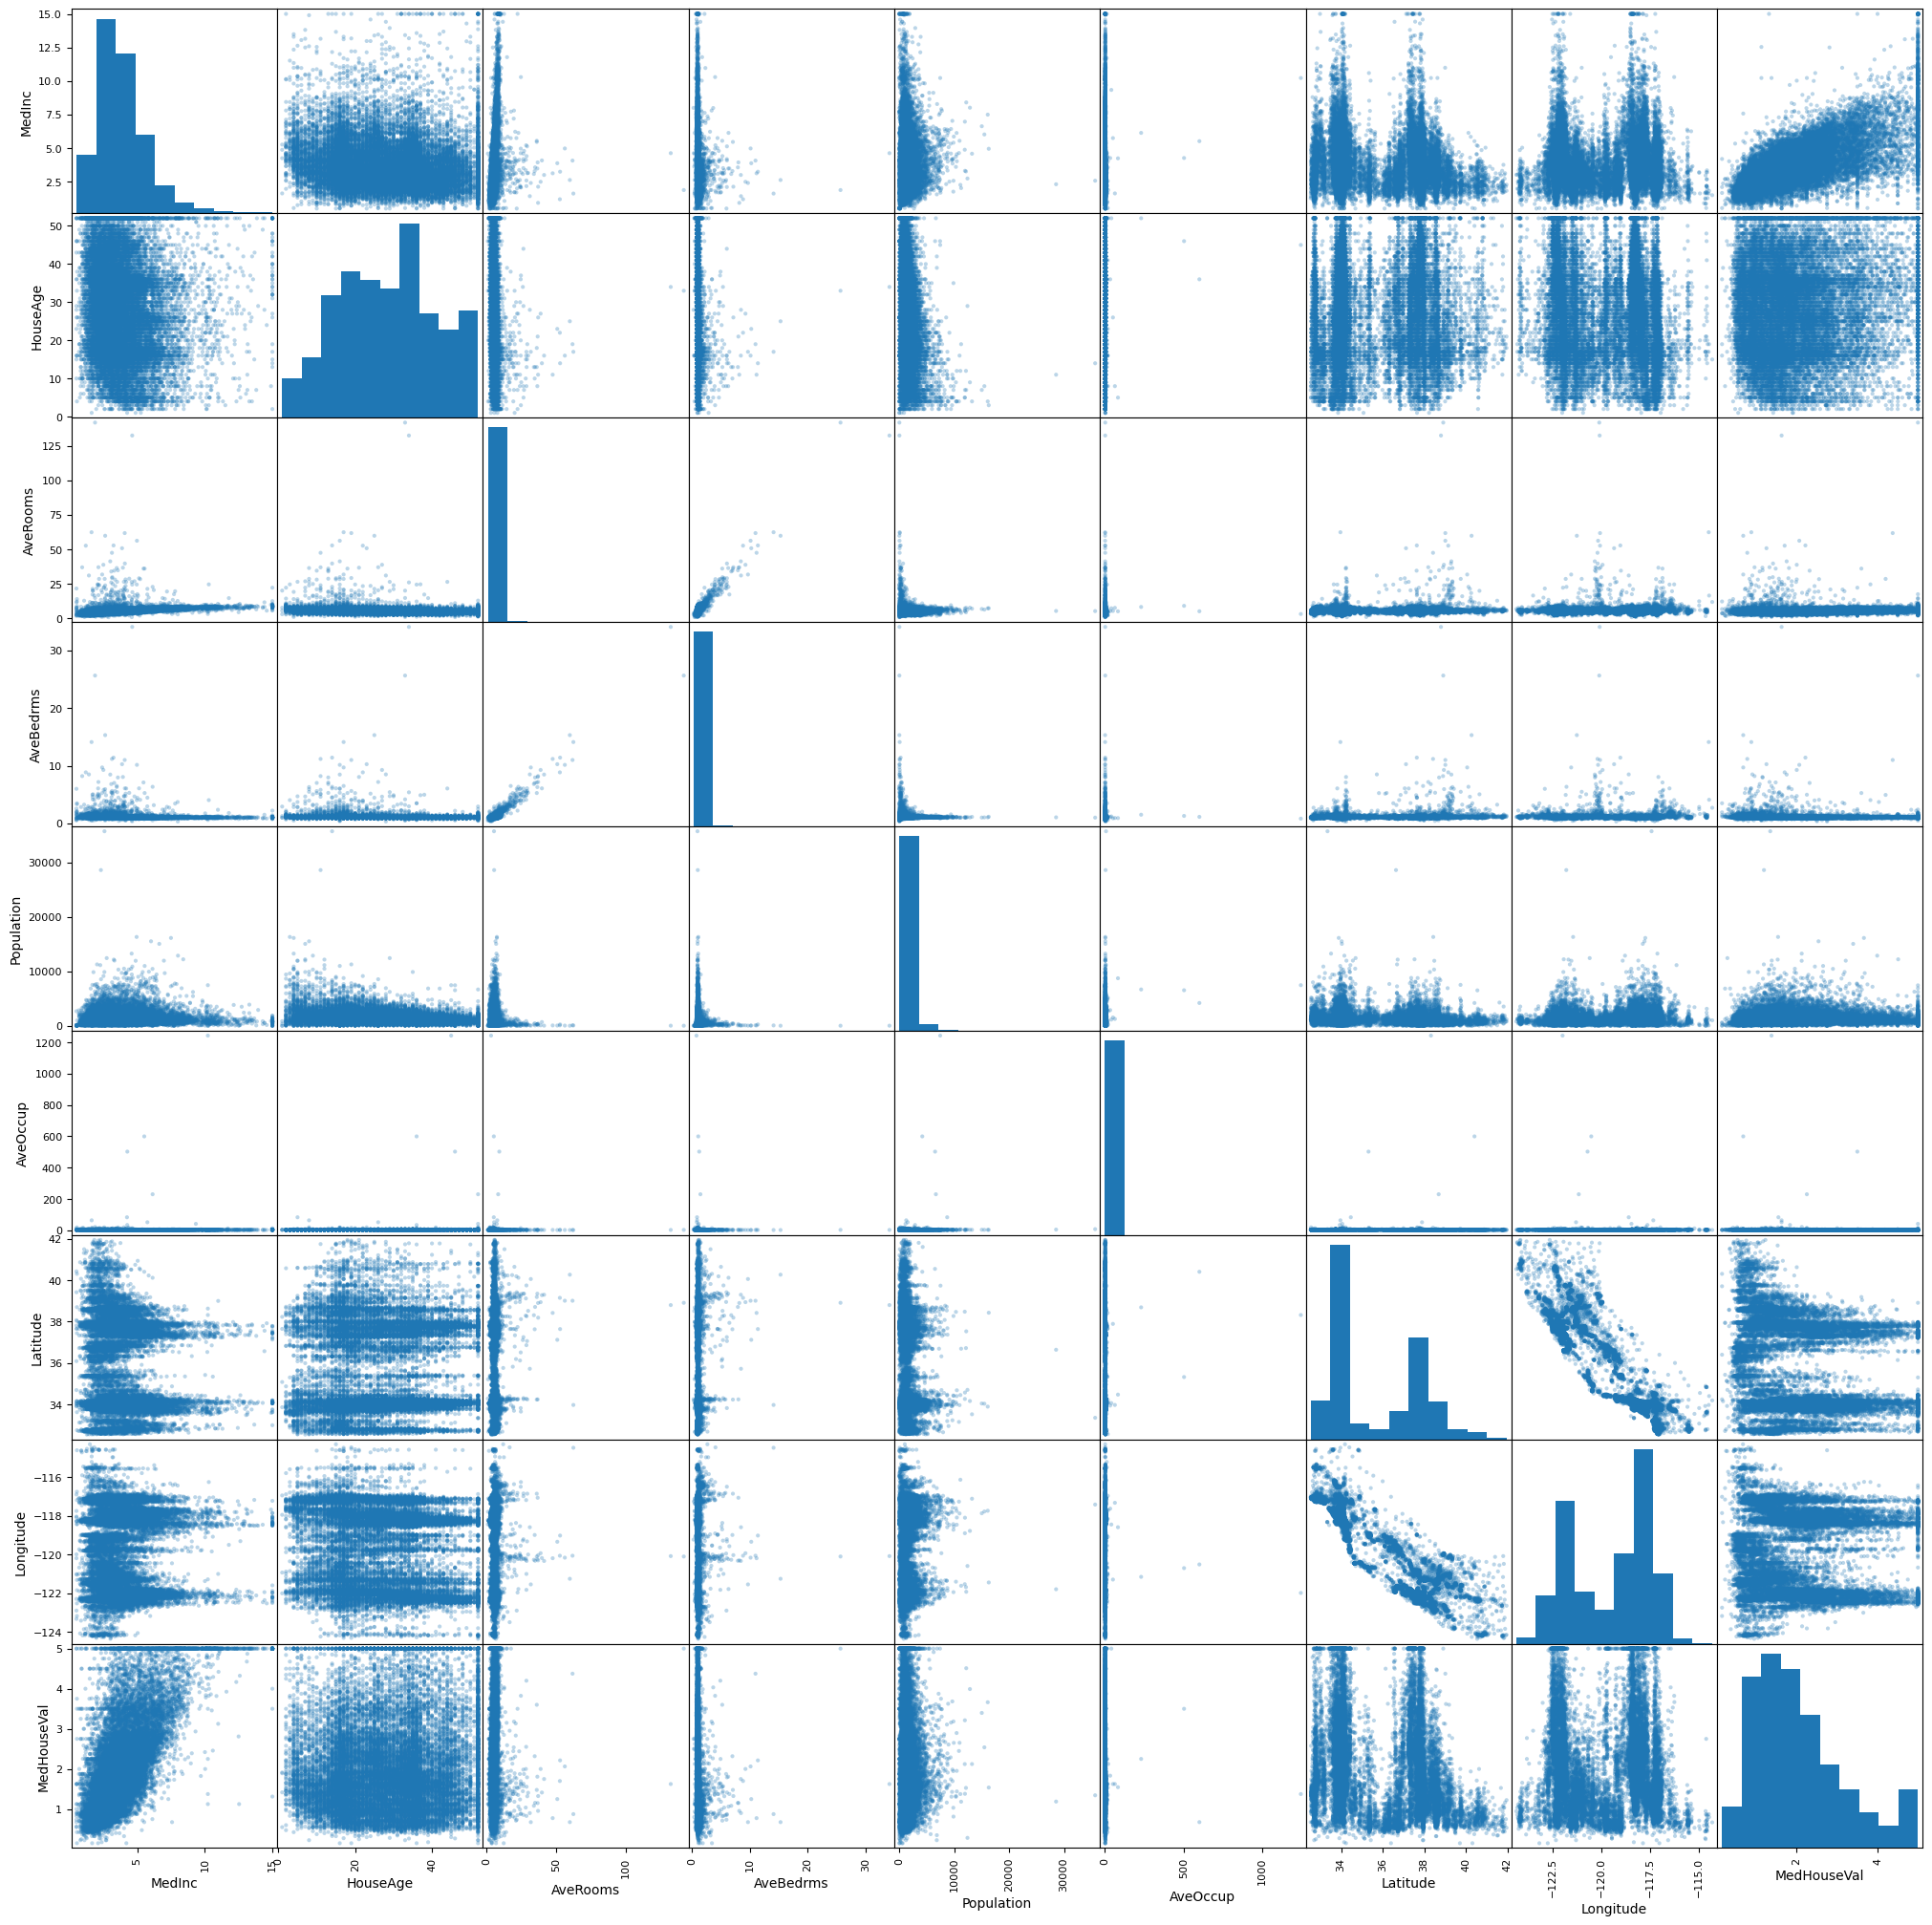

In [6]:
# 相関係数
display(df.corr())

from pandas.plotting import scatter_matrix
sm = scatter_matrix(df, figsize = (25, 25), alpha = 0.3, diagonal = 'hist')

### 単回帰分析による教師あり学習

In [7]:
#　説明変数・目的変数
x = df[['MedInc']]
y = df['MedHouseVal']

display(x)
display(y)

,MedInc
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462
...,...
20635,1.5603
20636,2.5568
20637,1.7000
20638,1.8672


0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [8]:
# 学習データとテストデータの分割

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, test_size=0.3, random_state=0)


In [9]:
# 単回帰分析結果

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
print("切片 = ", model.intercept_)
pd.DataFrame({"変数名": x_train.columns, "係数": model.coef_})

切片 =  0.43306075947778555


,変数名,係数
0,MedInc,0.422899


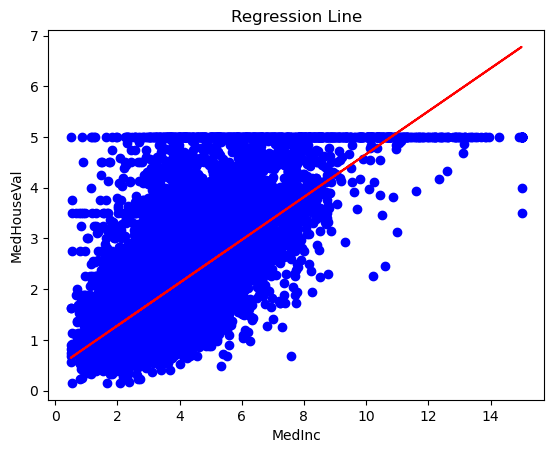

In [10]:
# グラフによる可視化

import matplotlib.pyplot as plt
plt.scatter(x_train, y_train, color="blue")

plt.title("Regression Line")
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.plot(x_train['MedInc'], model.predict(x_train), color="red")
plt.show()

In [11]:
# 決定係数

from sklearn.metrics import r2_score
print("r^2 (train): ", r2_score(y_train, model.predict(x_train)))
print("r^2 (test): ", r2_score(y_test, model.predict(x_test)))

r^2 (train):  0.4805817090322434
r^2 (test):  0.4564978967949699


### 重回帰分析による教師あり学習

In [12]:
# 学習データとテストデータの分割

x = df.drop(['MedHouseVal'], axis=1)
y = df['MedHouseVal']

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, test_size=0.3, random_state=0)

In [13]:
model = LinearRegression()
model.fit(x_train, y_train)
print("切片 = ", model.intercept_)
pd.DataFrame({"変数名": x_train.columns, "係数": model.coef_}).sort_values(by="係数")

切片 =  -36.015755977895026


,変数名,係数
7,Longitude,-0.423454
6,Latitude,-0.409045
2,AveRooms,-0.118104
5,AveOccup,-0.004086
4,Population,-0.000009
1,HouseAge,0.009185
0,MedInc,0.446777
3,AveBedrms,0.642251


In [14]:
# 決定係数

print("r^2 (train): ", r2_score(y_train, model.predict(x_train)))
print("r^2 (test): ", r2_score(y_test, model.predict(x_test)))

r^2 (train):  0.6112583475310978
r^2 (test):  0.5926096960745021
